# Entrenamiento: Clústering y regresión para la predicción de precios de Idealista

**Propósito**: Entrenar y evaluar modelos de regresión híbridos (clústering + regresión en cada grupo) para predecir el precio de las viviendas, compararemos varios modelos para obtener el mejor.

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.cluster import DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, pairwise_distances_argmin_min
from sklearn.base import BaseEstimator, RegressorMixin

#Importar utilidades de TFM
sys.path.insert(0, '/tfm/python_notebooks')
from tfm_lib import utils as tfm_utils


In [2]:
#Inicializar sesión de Spark
spark=tfm_utils.get_spark_session(app_name="ML_training")

#Cargar los datos desde Delta Lake
df_spark=tfm_utils.read_from_delta(spark, "ml.idealista_crem.dataset_for_analysis")
df=df_spark.toPandas()
print(f"Dataset cargado con éxito. Dimensiones: {df.shape}")

#Definimos la semilla de aleatoriedad que utilizaremos
random_state=55

Dataset cargado con éxito. Dimensiones: (10509, 22)


## Clustering.

Lo primero que haremos será dividir los datos de origen en dos grupos, aquellos con los que entrenaremos el modelo y aquellos que nos servirán para testear los modelos obtenidos, nos quedaremos un un 85% de los datos para testo.

In [3]:
#Definir variables independientes (X) y dependiente (y)
X=df.drop(columns=['price'])
y=df['price']

#Dividir en conjuntos de entrenamiento y test (85% train, 15% test)
X_train, X_test, y_train, y_test=train_test_split(
    X, y, test_size=0.15, random_state=random_state
)

print(f"Entrenamiento: {X_train.shape[0]} muestras")
print(f"Testeo: {X_test.shape[0]} muestras")

Entrenamiento: 8932 muestras
Testeo: 1577 muestras


Aplicamos DBSCAN para obtener grupos en los datos. Hay que decir que para hacer los grupos, o clusters usaremos solo las variables características, esto es importante. Lo que queremos predecir es el precio de un inmueble a partir de sus características, si usaramos el precio para hacer ese clústering, además de no tener sentido con lo que queremos hacer, estaríamos comentiendo un sesgo respecto esa variable, los grupos se llevarían a cabo respecto a dicho valor. Así mismo, la división entre dataset de entrenamiento y de testeo la hacemos antes de entrenar cualquier modelo de regresión. Cuando apliquemos un testeo vamos a querer observar el comportamiento de todo el proceso predictivo, no solo de una parte de él.

In [4]:
#Creamos un modelo DBSCAN con eps=0., el radio del vecindario, 
#y min_samples=3, la cantidad de vecinos para pertenecer a un grupo
dbscan = DBSCAN(eps=2, min_samples=15)

#Ajustamos para obtener los clusters
cluster_labels = dbscan.fit_predict(X_train)

#Recuperamos las etiquetas a los datos de entrenamiento
X_train['cluster']=cluster_labels

#Veamos cuantos registros hay por grupo
display(X_train.groupby("cluster").size().reset_index(name="n_observaciones"))

,cluster,n_observaciones
0,-1,74
1,0,5275
2,1,2306
3,2,1277


Ahora bien, el problema con este modelo es que podemos crear los clústeres a partir de un subconjunto y luego, con muestras nuevas, no podemos predecir a qué grupo pertenecen dichas muestras, al menos no con un método directo, lo que sí podemos hacer es construir una estratégia con la cual, crear los clusters a partir de nuestros datos de entrenamiento y usar el resultado para asignar a a un grupo una nueva muestra. 

In [5]:
def predict_dbscan(dbscan_model, X_new):
    """
    Asigna nuevas muestras (X_new) a los clusteres DBSCAN ya entrenados.
    
    Estrategia:
    Asigna cada nueva muestra al cluster de su punto nucleo mas cercano si la distancia es menor o igual a 'eps'. De lo contrario, la clasifica como ruido (-1).
    """   
    #Extraemos los puntos nucleo de los grupos
    core_samples=dbscan_model.components_
    
    #Extraemos las etiquetas de los nucleos
    core_labels=dbscan_model.labels_[dbscan_model.core_sample_indices_]
    
    #Calculamos la distancia al nucleo mas cercano para cada muestra
    #pairwise_distances_argmin_min devuelve:
    #    - index: El indice del punto nucleo mas cercano.
    #    - dist: La distancia euclidiana hacia ese punto 
    #           nucleo mas cercano.
    closest_core_idx, distances=pairwise_distances_argmin_min(X_new, core_samples)
    
    #Aplicamos la regla de asignacion:
    #    Si dist <= eps: se le asigna la etiqueta de ese punto nucleo.
    #    Si dist > eps: se le asigna -1 (ruido).
    predicted_labels = np.where(
        distances <= dbscan_model.eps, 
        core_labels[closest_core_idx], 
        -1
    )
    
    return predicted_labels

X_test['cluster']=predict_dbscan(dbscan, X_test)

#Veamos cuantos registros hay por grupo
display(X_test.groupby("cluster").size().reset_index(name="n_observaciones"))

,cluster,n_observaciones
0,-1,14
1,0,912
2,1,430
3,2,221


Reconstruimos los dataset de entrenamiento y testeo con su precio para poder trabajar con los datos de mejor manera de forma posterior.

In [6]:
df_train_full = X_train.copy()
df_train_full['price'] = y_train

df_test_full = X_test.copy()
df_test_full['price'] = y_test

Definimos una función con la cual entrenar varios modelos de regresión y escoger el mejor, para decidir cual es el mejor de esos modelos utilizaremos la métrica del error medio en valor absoluto. Para el entrenamiento de estos modelos vamos a asumir que, como resultado del clústering anterior, los datos de cada clúster se parecen lo suficiente entre sí, precisamente por eso hemos escogido dicho algoritmo de clústering, sin embargo, ahora, para entrenar los modelos de regresión, sí que tenemos a nuestra disposición la variable de precios, por lo que, lo primero que haremos, será eliminar los outliers locales de cada conjunto respecto a esta nueva variable. Una vez hecho esto entraremos en el entrenamiento de cada modelo que utilizamos para dicho clúster.

In [7]:
def delete_outliers_iqr(df, columna='price', factor=1.5):
    """
    Elimina outliers usando el método IQR
    """
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1
    
    limite_inferior = Q1 - factor * IQR
    limite_superior = Q3 + factor * IQR
    
    # Filtrar datos
    df_filtrado = df[(df[columna] >= limite_inferior) & 
                     (df[columna] <= limite_superior)]
    
    print(f"Registros eliminados: {len(df) - len(df_filtrado)} ({100*(1-len(df_filtrado)/len(df)):.1f}%)")
    print(f"Límites: [{limite_inferior:.2f}, {limite_superior:.2f}]")
    
    return df_filtrado

In [8]:
def get_best_local_model(df_full, cluster_label):
    #Filtramos los datos del cluster a procesar
    df_local=df_full[df_full['cluster']==cluster_label].copy()

    #Eliminamos los outliers respecto del precio
    df_local=delete_outliers_iqr(df_local)
        
    #Definir variables independientes (X) y dependiente (y)
    X_local=df_local.drop(columns=['price','cluster'])
    y_local=df_local['price']
    
    #Dividir en conjuntos de entrenamiento y test (85% train, 15% test)
    X_local_train, X_local_test, y_local_train, y_local_test=train_test_split(X_local, y_local, test_size=0.15
                                                                              , random_state=random_state)

    #Metemos validadción cruzada
    cv=KFold(
        n_splits=5,
        shuffle=True,
        random_state=random_state
    )
    
    ################################################################################
    #Primer modelo: Random Forest
    #Random Forest Regressor es un modelo de aprendizaje automático basado en árboles de decisión. 
    rf_base=RandomForestRegressor(random_state=random_state, n_jobs=-1)

    rf_param_grid={
        'n_estimators': [20, 50, 100, 150, 200, 250, 300],
        'max_depth': [8, 10, 12, 14, 16]
    }
    
    #Nos quedamos con el modelo con menor error medio absoluto
    rf_grid=GridSearchCV(rf_base, rf_param_grid, cv=cv, scoring='neg_mean_absolute_error')
    rf_grid.fit(X_local_train, y_local_train)
    
    best_rf=rf_grid.best_estimator_
    rf_best_params=rf_grid.best_params_
    print(50*"#")
    print(f"Mejores parámetros para Random Forest: {rf_best_params}")
    
    #Predicciones y métricas
    y_pred_train_rf = best_rf.predict(X_local_train)
    y_pred_test_rf = best_rf.predict(X_local_test)
    mae_train_rf = mean_absolute_error(y_local_train, y_pred_train_rf)
    mae_test_rf = mean_absolute_error(y_local_test, y_pred_test_rf)
    
    print(f"MAE Train: {mae_train_rf:.2f} €")
    print(f"MAE Test: {mae_test_rf:.2f} €")
    
    ################################################################################
    #Segundo modelo: Gradient Boosting
    #Gradient Boosting es un modelo de aprendizaje automático basado en la combinación secuencial de múltiples árboles de decisión,
    #pero en este caso cada árbol se entrena para corregir los errores cometidos por los árboles anteriores, 
    #mejorando progresivamente la capacidad predictiva de todo el conjunto.
    #Definimos el GBR de base
    gbr_base=GradientBoostingRegressor(random_state=random_state)
    
    #Definir el grid de parámetros a probar
    gbr_param_grid={
        'n_estimators': [50, 70, 90, 120, 150, 200, 250],       'max_depth': [5, 8, 10, 12, 14, 16],
        'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.5],   'subsample': [0.7, 0.8, 0.9],
        'min_samples_split': [2, 5, 10],           'min_samples_leaf': [1, 2, 4]
    }
       
    #Configurar Grid Search
    gbr_grid_search=GridSearchCV(estimator=gbr_base, param_grid=gbr_param_grid,
        scoring='neg_mean_absolute_error',  cv=cv, 
        n_jobs=-1, verbose=1, return_train_score=True
    )
    
    #Ejecutar Grid Search
    gbr_grid_search.fit(X_local_train, y_local_train)
    
    #Mejores parámetros y mejor score
    gbr_best_params = gbr_grid_search.best_params_
    print(50*"#")
    print(f"Mejores parámetros para Gradient Boosting: {gbr_best_params}")
    
    print("\n===Mejores resultados===")
    print(f"Mejores parámetros: {gbr_best_params}")
    print(f"Mejor MAE (validación cruzada): {gbr_grid_search.best_score_:.4f}")
    
    #Obtener el mejor modelo
    best_gbr = gbr_grid_search.best_estimator_
    
    #Evaluar en train y test sets
    y_pred_train_gbr = best_gbr.predict(X_local_train)
    y_pred_test_gbr = best_gbr.predict(X_local_test)
    mae_train_gbr = mean_absolute_error(y_local_train, y_pred_train_gbr)
    mae_test_gbr = mean_absolute_error(y_local_test, y_pred_test_gbr)
    
    print(f"MAE Train: {mae_train_gbr:.2f} €")
    print(f"MAE Test: {mae_test_gbr:.2f} €")

    ################################################################################
    #Tercer Modelo: Support Vector Regressor
    #Support Vector Regression (SVR) es un modelo de regresión que busca encontrar la relación entre las variables de entrada
    #y la variable objetivo minimizando los errores de predicción y evitando al mismo tiempo que el modelo se adapte en exceso
    #a los datos de entrenamiento, evitando el sobre ajuste.

    #Modelo base
    svr_base=SVR()
    
    svr_param_grid={'C': [1000, 10_000, 100_000,500_000], 'epsilon': [1_000, 10_000, 15_000, 20_000]}
    
    svr_grid_search=GridSearchCV(estimator=svr_base, param_grid=svr_param_grid,
                        scoring='neg_mean_absolute_error', cv=cv, 
                        n_jobs=-1, verbose=1, return_train_score=True )
    
    #Ejecutar el grid search
    print("Iniciando Grid Search...")
    svr_grid_search.fit(X_local_train, y_local_train)
    
    #Mejores parámetros y mejor score
    svr_best_params=svr_grid_search.best_params_
    print(50*"#")
    print(f"Mejores parámetros para Support Vector Regressor: {svr_best_params}")
    
    #Evaluar el mejor modelo en el conjunto de prueba
    best_svr = svr_grid_search.best_estimator_
    y_pred_train_svr = best_svr.predict(X_local_train)
    y_pred_test_svr = best_svr.predict(X_local_test)
    mae_train_svr = mean_absolute_error(y_local_train, y_pred_train_svr)
    mae_test_svr = mean_absolute_error(y_local_test, y_pred_test_svr)
    
    print(f"MAE Train: {mae_train_svr:.2f} €")
    print(f"MAE Test: {mae_test_svr:.2f} €")

    ################################################################################
    #________________________IDENTIFICACION_DEL_MEJOR_MODELO________________________
    metrics = {
        'Modelo': [
            'Random Forest Regressor',
            'Gradient Boosting Regressor',
            'SVR'
        ],
        'MAE Train': [mae_train_rf, mae_train_gbr, mae_train_svr],
        'MAE Test': [mae_test_rf, mae_test_gbr, mae_test_svr],
        'Best_params': [str(rf_best_params), str(gbr_best_params), str(svr_best_params)]
    }

    df_metrics = pd.DataFrame(metrics)
    print(df_metrics.to_string(index=False))
    
    #Identificar el mejor modelo respecto al MAE del dataset de entrenamiento local
    best_model_idx = df_metrics['MAE Train'].idxmin()
    best_model_name = df_metrics.loc[best_model_idx, 'Modelo']
    best_model_params = df_metrics.loc[best_model_idx, 'Best_params']
    best_mae_train = df_metrics.loc[best_model_idx, 'MAE Train']
    best_mae_test = df_metrics.loc[best_model_idx, 'MAE Test']
    
    print(f"\nEl mejor modelo es: {best_model_name}")
    print(f"\tpara los parámetros {best_model_params} con un MAE Train de {best_mae_train:.2f} €")
    print(f"\tel MAE Test para este modelo es de {best_mae_test:.2f} €")
    
    best_model_list = [best_rf, best_gbr, best_svr]
    best_model = best_model_list[best_model_idx]


    ##############################################################################
    #_____________________________Predicciones_Locales____________________________
    
    y_pred_train = best_model.predict(X_local_train)
    y_pred_test = best_model.predict(X_local_test)
    
    #Entrenamiento
    df_train=X_local_train.copy()
    df_train["price"]=y_local_train.values
    df_train["price_predict"]=y_pred_train
    df_train["tipo_dato"]="entrenamiento"
    
    #Testeo
    df_test=X_local_test.copy()
    df_test["price"]=y_local_test.values
    df_test["price_predict"]=y_pred_test
    df_test["tipo_dato"]="test_local"
    
    df_cluster=pd.concat([df_train, df_test], axis=0, ignore_index=True)
    df_cluster["cluster"]=cluster_label
    
    return best_model, df_cluster
    

In [9]:
#Cluster 0
best_model_0, df_train_0=get_best_local_model(df_train_full, 0)

#Hacemos las predicciones para el dataset de testeo (global) que han caído en este cluster
df_test_0=df_test_full[df_test_full['cluster']==0]

X_test_0=df_test_0.drop(columns=['price','cluster'])
Y_test_0=df_test_0['price']
Y_predict_0=best_model_0.predict(X_test_0)

#Mostramos por pantalla el error médio absoluto dentro del dataset de entrenamiento
mae_0=mean_absolute_error(Y_test_0, Y_predict_0)
print(f"El Error Medio Absoluto dentro del dataset de entrenamiento global para el cluster 0 es de {mae_0}€")

df_test=X_test_0.copy()
df_test["price"]=Y_test_0.values
df_test["price_predict"]=Y_predict_0
df_test["tipo_dato"]="test_global"
df_test['cluster']=0

df_full_0=pd.concat([df_train_0, df_test], axis=0, ignore_index=True)
#Pasamos a pyspark
df_full_0=spark.createDataFrame(df_full_0)

Registros eliminados: 232 (4.4%)
Límites: [-120062.50, 512037.50]
##################################################
Mejores parámetros para Random Forest: {'max_depth': 14, 'n_estimators': 300}
MAE Train: 23344.25 €
MAE Test: 44868.60 €
Fitting 5 folds for each of 5670 candidates, totalling 28350 fits
##################################################
Mejores parámetros para Gradient Boosting: {'learning_rate': 0.05, 'max_depth': 8, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 120, 'subsample': 0.7}

===Mejores resultados===
Mejores parámetros: {'learning_rate': 0.05, 'max_depth': 8, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 120, 'subsample': 0.7}
Mejor MAE (validación cruzada): -44671.0756
MAE Train: 27159.93 €
MAE Test: 45882.11 €
Iniciando Grid Search...
Fitting 5 folds for each of 16 candidates, totalling 80 fits
##################################################
Mejores parámetros para Support Vector Regressor: {'C': 500000, 'epsilon': 15000

In [10]:
#Cluster 1
best_model_1, df_train_1=get_best_local_model(df_train_full, 1)

#Hacemos las predicciones para el dataset de testeo (global) que han caído en este cluster
df_test_1=df_test_full[df_test_full['cluster']==1]

X_test_1=df_test_1.drop(columns=['price','cluster'])
Y_test_1=df_test_1['price']
Y_predict_1=best_model_1.predict(X_test_1)

#Mostramos por pantalla el error médio absoluto dentro del dataset de entrenamiento
mae_1=mean_absolute_error(Y_test_1, Y_predict_1)
print(f"El Error Medio Absoluto dentro del dataset de entrenamiento global para el cluster 1 es de {mae_1}€")

df_test=X_test_1.copy()
df_test["price"]=Y_test_1.values
df_test["price_predict"]=Y_predict_1
df_test["tipo_dato"]="test_global"
df_test['cluster']=1

df_full_1=pd.concat([df_train_1, df_test], axis=0, ignore_index=True)
#Pasamos a pyspark
df_full_1=spark.createDataFrame(df_full_1)

Registros eliminados: 114 (4.9%)
Límites: [-155000.00, 605000.00]
##################################################
Mejores parámetros para Random Forest: {'max_depth': 8, 'n_estimators': 250}
MAE Train: 53511.20 €
MAE Test: 67611.21 €
Fitting 5 folds for each of 5670 candidates, totalling 28350 fits
##################################################
Mejores parámetros para Gradient Boosting: {'learning_rate': 0.05, 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 120, 'subsample': 0.7}

===Mejores resultados===
Mejores parámetros: {'learning_rate': 0.05, 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 120, 'subsample': 0.7}
Mejor MAE (validación cruzada): -64954.5622
MAE Train: 54927.30 €
MAE Test: 68109.95 €
Iniciando Grid Search...
Fitting 5 folds for each of 16 candidates, totalling 80 fits
##################################################
Mejores parámetros para Support Vector Regressor: {'C': 100000, 'epsilon': 20000}

In [11]:
#Cluster 2
best_model_2, df_train_2=get_best_local_model(df_train_full, 2)

#Hacemos las predicciones para el dataset de testeo (global) que han caído en este cluster
df_test_2=df_test_full[df_test_full['cluster']==2]

X_test_2=df_test_2.drop(columns=['price','cluster'])
Y_test_2=df_test_2['price']
Y_predict_2=best_model_2.predict(X_test_2)

#Mostramos por pantalla el error médio absoluto dentro del dataset de entrenamiento
mae_2=mean_absolute_error(Y_test_2, Y_predict_2)
print(f"El Error Medio Absoluto dentro del dataset de entrenamiento global para el cluster 2 es de {mae_2}€")

df_test=X_test_2.copy()
df_test["price"]=Y_test_2.values
df_test["price_predict"]=Y_predict_2
df_test["tipo_dato"]="test_global"
df_test['cluster']=2

df_full_2=pd.concat([df_train_2, df_test], axis=0, ignore_index=True)
#Pasamos a pyspark
df_full_2=spark.createDataFrame(df_full_2)

Registros eliminados: 76 (6.0%)
Límites: [-177500.00, 626500.00]
##################################################
Mejores parámetros para Random Forest: {'max_depth': 8, 'n_estimators': 20}
MAE Train: 46430.82 €
MAE Test: 64346.00 €
Fitting 5 folds for each of 5670 candidates, totalling 28350 fits
##################################################
Mejores parámetros para Gradient Boosting: {'learning_rate': 0.05, 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 90, 'subsample': 0.7}

===Mejores resultados===
Mejores parámetros: {'learning_rate': 0.05, 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 90, 'subsample': 0.7}
Mejor MAE (validación cruzada): -64660.4216
MAE Train: 52270.19 €
MAE Test: 64190.90 €
Iniciando Grid Search...
Fitting 5 folds for each of 16 candidates, totalling 80 fits
##################################################
Mejores parámetros para Support Vector Regressor: {'C': 100000, 'epsilon': 15000}
M

In [12]:
#Unimos todo y guardamos
df_full=df_full_0.union(df_full_1).union(df_full_2)
df_normalized = tfm_utils.normalize_df(df_full)

#Guardamos
ml_table_name = "ml.idealista_crem.regresion_results"
delta_path = tfm_utils.full_table_path(ml_table_name)

print(f"Escribiendo {df_normalized.count()} registros en la Delta Table: {ml_table_name}")
print(f"Destino: {delta_path}")

# Escritura en modo overwrite
(df_normalized
    .write
    .option("overwriteSchema","true")
    .mode("overwrite")
    .format("delta")
    .save(delta_path)
)

Escribiendo 9999 registros en la Delta Table: ml.idealista_crem.regresion_results
Destino: /tfm/delta_lake/ml/idealista_crem/regresion_results


## Pequeña visualización de uno de los arboles de decisión del modelo del clúster 0
Vamos a dibujar un pequeño esquema de las decisiones que toma uno de los árboles de decisión que intervienen en el mejor de los modelos que forman parte del mejor modelo del clúster 0.

Esto lo hacemos simplemente para visualizar dicho diagrama.

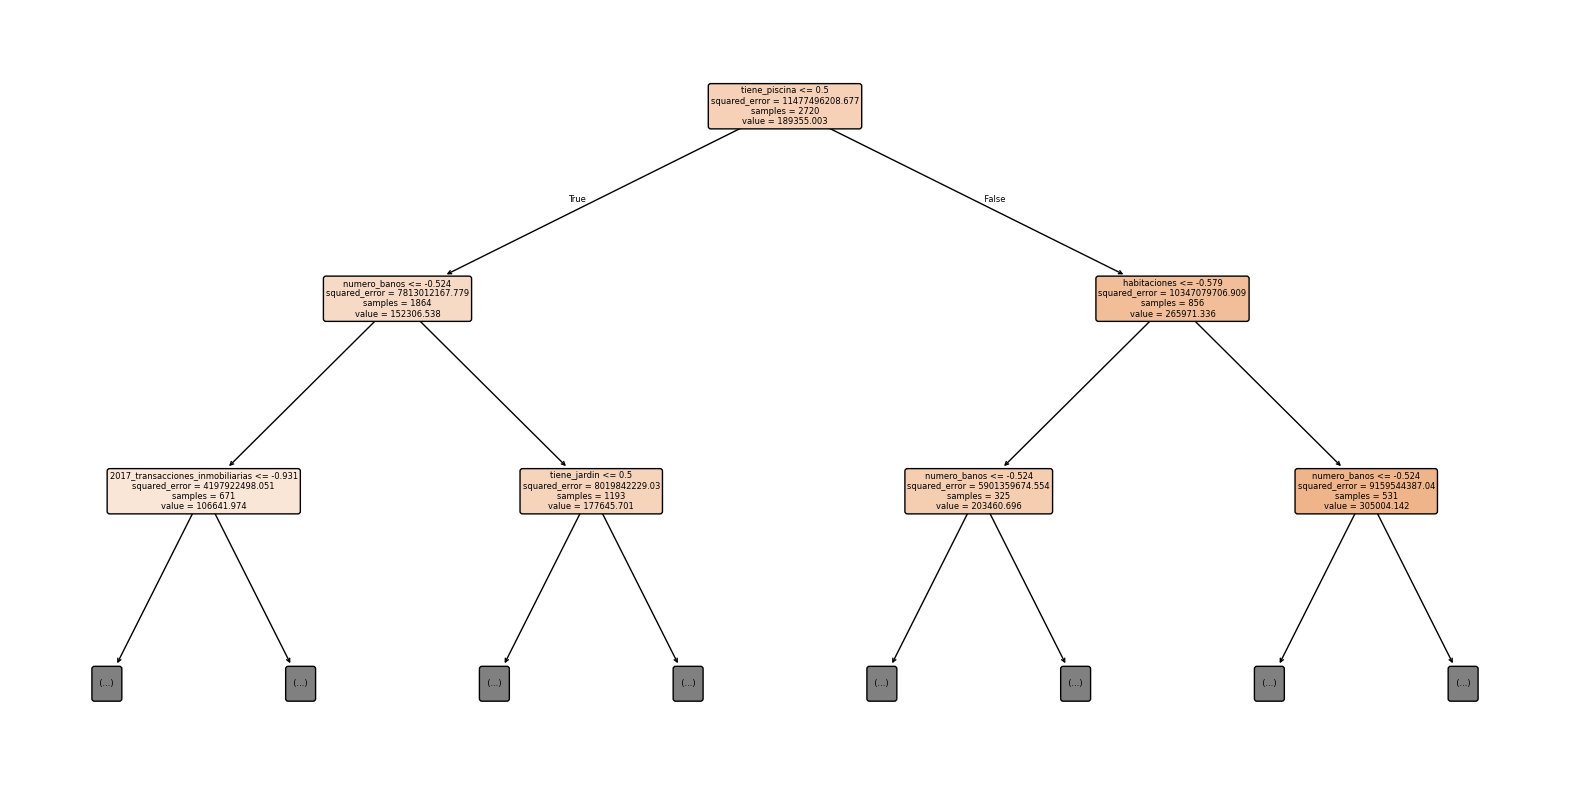

In [16]:
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
tree.plot_tree(
    best_model_0.estimators_[0],
    filled=True,
    feature_names=X.columns,
    rounded=True,
    max_depth=2
)
plt.show()